In [31]:
import torch
import mylib
import matplotlib.pyplot as plt

from torch import nn

In [34]:
def relu(X):
    a = torch.zeros_like(X)
    return torch.max(X, a)

def net(X):
    X = X.reshape((-1, num_inputs))
    H = relu(X@W1 + b1)
    return (H@W2 + b2)


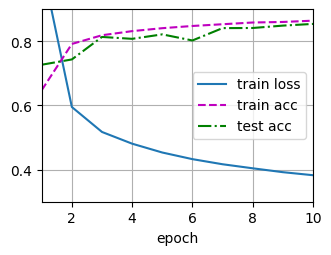

In [ ]:
batch_size = 256
train_iter, test_iter = mylib.load_data_fashion_mnist(batch_size)
num_epochs, lr = 10, 0.1

# 选择2的若干次幂作为层的宽度
# 因为内存在硬件中的分配和寻址方式，这么做往往可以在计算上更高效
num_inputs, num_outputs, num_hiddens = 784, 10, 256

W1 = nn.Parameter(torch.randn(num_inputs, num_hiddens, requires_grad=True) * 0.01)
b1 = nn.Parameter(torch.zeros(num_hiddens, requires_grad=True))
W2 = nn.Parameter(torch.randn(num_hiddens, num_outputs, requires_grad=True) * 0.01)
b2 = nn.Parameter(torch.zeros(num_outputs, requires_grad=True))

params = [W1, b1, W2, b2]

loss = nn.CrossEntropyLoss(reduction='none')
updater = torch.optim.SGD(params, lr = lr)
mylib.train(net, train_iter, test_iter, loss, num_epochs, updater)


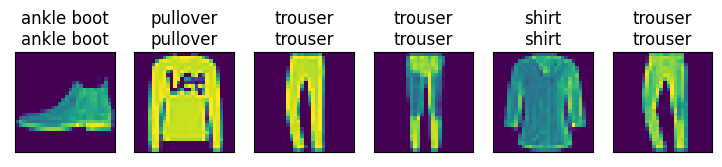

In [39]:
mylib.predict(net, test_iter)

In [29]:
a = torch.tensor([[1,2,3],[4,5,6]])
b = torch.tensor([[6,5,4],[3,2,1]])
print(torch.max(a, b))

tensor([[6, 5, 4],
        [4, 5, 6]])
